<a href="https://colab.research.google.com/github/omyahro/omyahro.github.io/blob/main/statistical_analysis_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Analysis & Data Preparation  
## Cancer Mortality Disparities Among Black and White Women in Georgia

This notebook prepares the capstone dataset for statistical analysis and machine learning by exploring patterns in cancer mortality among Black and White women in Georgia across 2016–2020 and 2020–2024. The analysis includes descriptive statistics, visual exploration, hypothesis testing, and pre-ML data diagnosis.

In [8]:
# Import the libraries
import numpy as np                  # Scientific Computing
import pandas as pd                 # Data Analysis
import matplotlib.pyplot as plt     # Plotting
import seaborn as sns               # Statistical Data Visualization
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.preprocessing import LabelEncoder

# Let's make sure pandas returns all the rows and columns for the dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Force pandas to display full numbers instead of scientific notation
# pd.options.display.float_format = '{:.0f}'.format

# Library to suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Define the file path (adjust to your folder location)
file_path = "/content/drive/My Drive/Georgia_Cancer_Mortality.csv"

# Read the file
df = pd.read_csv(file_path)
df.head()


,years,Region,BlackFemale_Deaths AllSites,WhiteFemale_Deaths AllSites,BlackFemale_Rate AllSites,WhiteFemale_Rate AllSites,BlackFemale_Deaths Colon,WhiteFemale_DeathsC,BlackFemale_Rate C,WhiteFemale_RateC,BlackFemale_Deaths L,WhiteFemale_DeathsL,BlackFemale_RateL,WhiteFemale_RateL,BlackFemale_DeathsB,WhiteFemale_DeathsB,BlackFemale_RateB,WhiteFemale_RateB
0,2016-2020,Georgia,12203,27853,138.7,127.0,1196.0,2335,13.8,10.8,2052,7142,23.5,31.7,2411,3933,26.5,18.4
1,2016-2020,Northwest,3153,2845,145.6,146.0,27.0,224,13.3,11.7,62,779,34.2,38.5,60,379,28.5,20.3
2,2016-2020,North Georgia,2031,1945,128.8,129.3,9.0,161,NaN,11.1,15,532,NaN,34.2,10,282,NaN,19.3
3,2016-2020,North,2888,2704,120.4,121.6,13.0,256,NaN,12.0,23,720,21.6,31.5,25,379,22.5,17.3
4,2016-2020,Cobb-Douglas,3069,2220,126.2,123.6,91.0,180,16.5,9.9,111,489,21.7,27.0,172,359,26.1,20.7


In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   years                        38 non-null     object 
 1   Region                       38 non-null     object 
 2   BlackFemale_Deaths AllSites  38 non-null     int64  
 3   WhiteFemale_Deaths AllSites  38 non-null     int64  
 4   BlackFemale_Rate AllSites    38 non-null     float64
 5   WhiteFemale_Rate AllSites    38 non-null     float64
 6   BlackFemale_Deaths Colon     37 non-null     float64
 7   WhiteFemale_DeathsC          38 non-null     int64  
 8   BlackFemale_Rate C           34 non-null     float64
 9   WhiteFemale_RateC            38 non-null     float64
 10  BlackFemale_Deaths L         38 non-null     int64  
 11  WhiteFemale_DeathsL          38 non-null     int64  
 12  BlackFemale_RateL            36 non-null     float64
 13  WhiteFemale_RateL     

,0
years,0
Region,0
BlackFemale_Deaths AllSites,0
WhiteFemale_Deaths AllSites,0
BlackFemale_Rate AllSites,0
WhiteFemale_Rate AllSites,0
BlackFemale_Deaths Colon,1
WhiteFemale_DeathsC,0
BlackFemale_Rate C,4
WhiteFemale_RateC,0


The dataset was checked for missing values, data types, and overall structure. This step ensures the data is clean enough for statistical analysis and future machine learning.

In [14]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   years                        38 non-null     object 
 1   Region                       38 non-null     object 
 2   BlackFemale_Deaths AllSites  38 non-null     int64  
 3   WhiteFemale_Deaths AllSites  38 non-null     int64  
 4   BlackFemale_Rate AllSites    38 non-null     float64
 5   WhiteFemale_Rate AllSites    38 non-null     float64
 6   BlackFemale_Deaths Colon     37 non-null     float64
 7   WhiteFemale_DeathsC          38 non-null     int64  
 8   BlackFemale_Rate C           34 non-null     float64
 9   WhiteFemale_RateC            38 non-null     float64
 10  BlackFemale_Deaths L         38 non-null     int64  
 11  WhiteFemale_DeathsL          38 non-null     int64  
 12  BlackFemale_RateL            36 non-null     float64
 13  WhiteFemale_RateL     

,0
years,0
Region,0
BlackFemale_Deaths AllSites,0
WhiteFemale_Deaths AllSites,0
BlackFemale_Rate AllSites,0
WhiteFemale_Rate AllSites,0
BlackFemale_Deaths Colon,1
WhiteFemale_DeathsC,0
BlackFemale_Rate C,4
WhiteFemale_RateC,0


Descriptive statistics were calculated to compare cancer mortality outcomes between Black and White women. Mean and median show the typical mortality level, while standard deviation shows how much the values vary across cancer types, counties, and time periods.

In [16]:
df[[
    "BlackFemale_Rate AllSites",
    "WhiteFemale_Rate AllSites"
]].describe()

,BlackFemale_Rate AllSites,WhiteFemale_Rate AllSites
count,38.000000,38.000000
mean,132.978947,129.018421
std,9.868272,13.491897
min,104.300000,97.700000
25%,126.850000,125.000000
50%,133.950000,129.400000
75%,139.850000,136.950000
max,148.600000,156.200000


In [17]:
df[[
    "BlackFemale_Deaths AllSites",
    "WhiteFemale_Deaths AllSites"
]].describe()

,BlackFemale_Deaths AllSites,WhiteFemale_Deaths AllSites
count,38.000000,38.000000
mean,1973.552632,3008.894737
std,2781.309906,6159.285207
min,69.000000,262.000000
25%,659.000000,1005.000000
50%,979.500000,1496.500000
75%,2301.750000,2179.000000
max,13285.000000,29316.000000


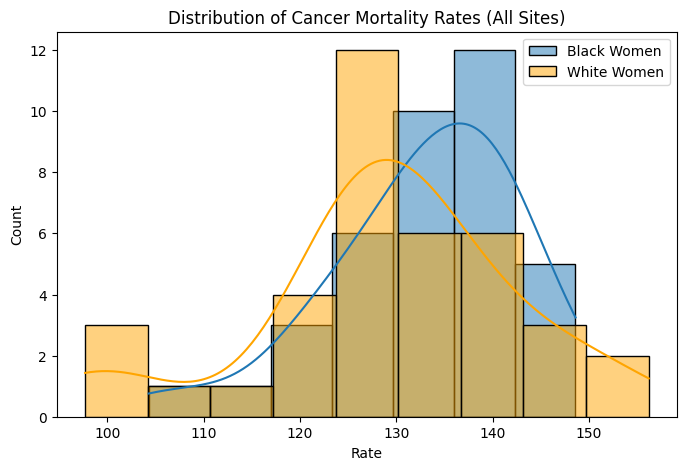

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["BlackFemale_Rate AllSites"], kde=True, label="Black Women")
sns.histplot(df["WhiteFemale_Rate AllSites"], kde=True, label="White Women", color="orange")
plt.legend()
plt.title("Distribution of Cancer Mortality Rates (All Sites)")
plt.xlabel("Rate")
plt.ylabel("Count")
plt.show()

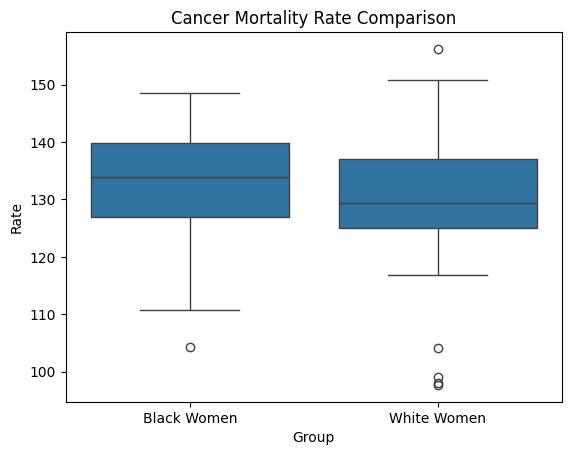

In [19]:
rates = pd.DataFrame({
    "Rate": pd.concat([
        df["BlackFemale_Rate AllSites"],
        df["WhiteFemale_Rate AllSites"]
    ]),
    "Group": ["Black Women"]*len(df) + ["White Women"]*len(df)
})

sns.boxplot(data=rates, x="Group", y="Rate")
plt.title("Cancer Mortality Rate Comparison")
plt.show()

The correlation matrix was used to check relationships between numeric variables and identify possible multicollinearity before machine learning.

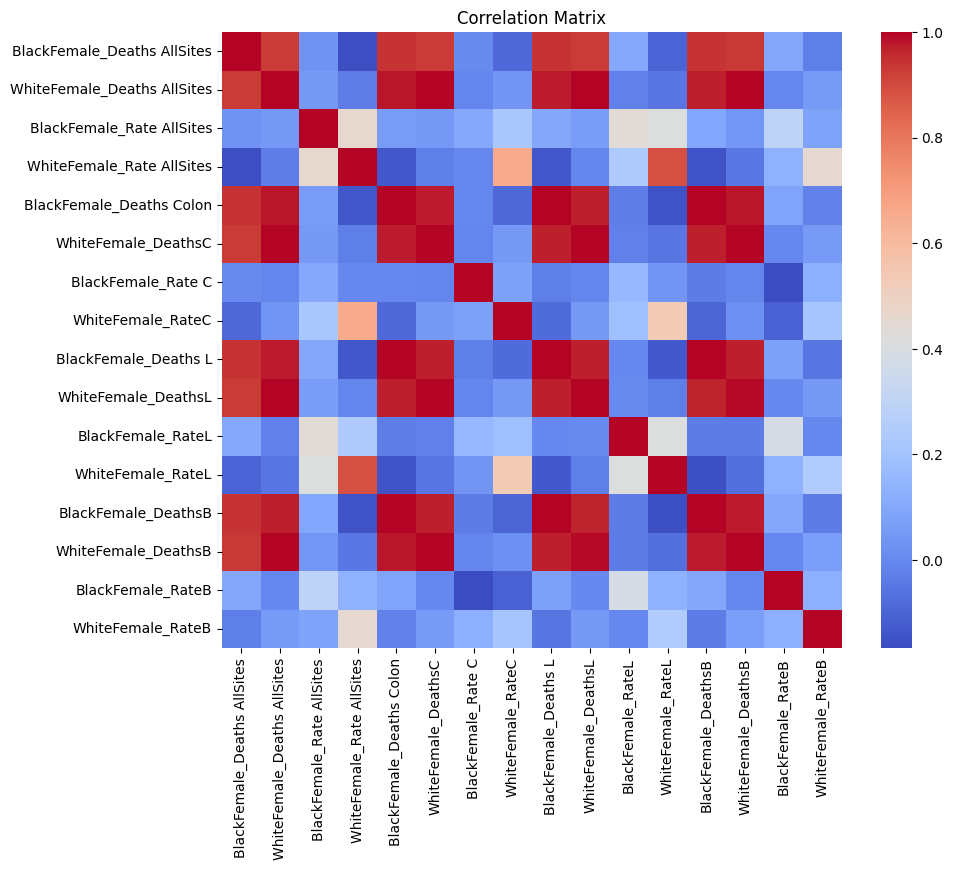

In [20]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Hypothesis Testing:

H0: There is no statistically significant difference in cancer mortality rates between Black and White women.

H1: There is a statistically significant difference in cancer mortality rates between Black and White women.

The p-value determines whether the difference is statistically significant. If the p-value is less than 0.05, we reject the null hypothesis and conclude that racial disparities in cancer mortality rates are statistically significant.

In [21]:
black_rates = df["BlackFemale_Rate AllSites"].dropna()
white_rates = df["WhiteFemale_Rate AllSites"].dropna()

t_stat, p_value = ttest_ind(black_rates, white_rates, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.4605639355974889
P-value: 0.14875531023532296


Missing values were checked to evaluate data integrity. If missing values are present, they should be handled based on the variable type. Numeric variables can be imputed using the median, while categorical variables can be filled using the mode. If very few rows are missing, deletion may also be reasonable.

In [22]:
df.isnull().sum()

,0
years,0
Region,0
BlackFemale_Deaths AllSites,0
WhiteFemale_Deaths AllSites,0
BlackFemale_Rate AllSites,0
WhiteFemale_Rate AllSites,0
BlackFemale_Deaths Colon,1
WhiteFemale_DeathsC,0
BlackFemale_Rate C,4
WhiteFemale_RateC,0


Outliers were assessed using a boxplot. Because cancer mortality rates can naturally vary by cancer type and county, extreme values were reviewed rather than automatically removed. Removing outliers without context could erase meaningful public health disparities.

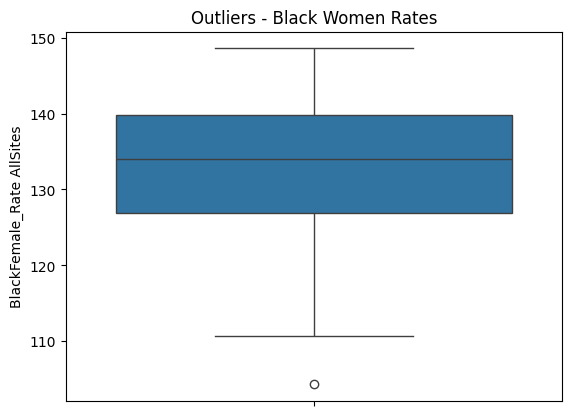

In [23]:
sns.boxplot(y=df["BlackFemale_Rate AllSites"])
plt.title("Outliers - Black Women Rates")
plt.show()

Multicollinearity was checked using a correlation matrix. If two independent variables are highly correlated, one may need to be dropped before modeling. This helps prevent the model from over-relying on repeated or redundant information.

In [24]:
numeric_df.corr()

,BlackFemale_Deaths AllSites,WhiteFemale_Deaths AllSites,BlackFemale_Rate AllSites,WhiteFemale_Rate AllSites,BlackFemale_Deaths Colon,WhiteFemale_DeathsC,BlackFemale_Rate C,WhiteFemale_RateC,BlackFemale_Deaths L,WhiteFemale_DeathsL,BlackFemale_RateL,WhiteFemale_RateL,BlackFemale_DeathsB,WhiteFemale_DeathsB,BlackFemale_RateB,WhiteFemale_RateB
BlackFemale_Deaths AllSites,1.000000,0.930302,0.031238,-0.157816,0.941743,0.929429,0.002363,-0.091008,0.941299,0.927946,0.102313,-0.098448,0.942955,0.931883,0.096323,-0.029580
WhiteFemale_Deaths AllSites,0.930302,1.000000,0.050510,-0.030017,0.977886,0.999744,-0.011451,0.034850,0.972959,0.997556,-0.021579,-0.055933,0.972209,0.999432,-0.003278,0.054899
BlackFemale_Rate AllSites,0.031238,0.050510,1.000000,0.457816,0.059411,0.049172,0.101866,0.218202,0.095164,0.061470,0.440504,0.414009,0.089169,0.038926,0.297218,0.079858
WhiteFemale_Rate AllSites,-0.157816,-0.030017,0.457816,1.000000,-0.134989,-0.026755,-0.005716,0.658028,-0.137314,-0.011223,0.242431,0.890041,-0.145991,-0.043671,0.134261,0.454448
BlackFemale_Deaths Colon,0.941743,0.977886,0.059411,-0.134989,1.000000,0.976384,-0.002667,-0.085529,0.997767,0.972585,-0.031377,-0.143905,0.998550,0.978517,0.085527,-0.019586
WhiteFemale_DeathsC,0.929429,0.999744,0.049172,-0.026755,0.976384,1.000000,-0.010525,0.049856,0.971545,0.997274,-0.024019,-0.054564,0.970905,0.999084,-0.006741,0.054527
BlackFemale_Rate C,0.002363,-0.011451,0.101866,-0.005716,-0.002667,-0.010525,1.000000,0.073852,-0.026170,-0.008163,0.159751,0.035975,-0.036216,-0.009524,-0.166478,0.126754
WhiteFemale_RateC,-0.091008,0.034850,0.218202,0.658028,-0.085529,0.049856,0.073852,1.000000,-0.083337,0.048795,0.185862,0.534753,-0.095395,0.021768,-0.108865,0.208819
BlackFemale_Deaths L,0.941299,0.972959,0.095164,-0.137314,0.997767,0.971545,-0.026170,-0.083337,1.000000,0.970929,-0.002185,-0.131987,0.997180,0.971996,0.073250,-0.053491
WhiteFemale_DeathsL,0.927946,0.997556,0.061470,-0.011223,0.972585,0.997274,-0.008163,0.048795,0.970929,1.000000,0.004208,-0.025309,0.966047,0.995158,-0.000680,0.051511


Class balance was checked because imbalanced categories can affect classification models. In this dataset, race categories were reviewed to determine whether one group was overrepresented. If imbalance is present, future models may use class weighting, oversampling, or careful evaluation metrics.

In [25]:
df["years"].value_counts()

,count
years,
2016-2020,19
2020-2024,19


Categorical variables were encoded to prepare the dataset for future machine learning models. This step allows non-numeric fields such as race, cancer type, county, and time period to be used in modeling.

In [27]:
df.to_csv("cleaned_data.csv", index=False)

This notebook completed the statistical foundation for the capstone project. The data was explored, tested, checked for quality issues, and prepared for future machine learning analysis.